# i. Introduction

================================================= <br>

Name  : Fernando Namora <br>
Date  : April 2026

This notebook is to build data modelling for sentiment analysis of IMDb reviews sentiment with ANN model within NLP domain <br>
(*This notebook is run on [Kaggle Notebook](https://www.kaggle.com/code/namorafn7/imdb-sentiment-analysis-bidirectionallstm-word2vec)*) <br>
================================================= <br>

## i.1. Dataset Information:

Source of dataset: <br>
[Kaggle-IMDB-Large-Movie-Reviews-Sentiment-Dataset-train-data](https://www.kaggle.com/datasets/jcblaise/imdb-sentiments?select=train.csv) (from Kaggle)

| Column | Description |
| --- | --- |
| `text` | movie reviews on IMDb platform |
| `sentiment` | reviews sentiment label with **0 (positive)** or **1 (negative)** |

> **Special Note:** <br>
> The dataset is sourced from Kaggle, and the data being used in this project is the one named `train.csv`. Since Kaggle's dataset mostly used for machine learning competitions, and the data `test.csv` is **unlabelled**. Therefore, in this project, we only use `train.csv` to act as complete dataset, which will then be split into training, validation, and testing sets for modeling purposes.

---

Citations from original source of dataset:
```
@InProceedings{maas-EtAl:2011:ACL-HLT2011,
  author    = {Maas, Andrew L.  and  Daly, Raymond E.  and  Pham, Peter T.  and  Huang, Dan  and  Ng, Andrew Y.  and  Potts, Christopher},
  title     = {Learning Word Vectors for Sentiment Analysis},
  booktitle = {Proceedings of the 49th Annual Meeting of the Association for Computational Linguistics: Human Language Technologies},
  month     = {June},
  year      = {2011},
  address   = {Portland, Oregon, USA},
  publisher = {Association for Computational Linguistics},
  pages     = {142--150},
  url       = {http://www.aclweb.org/anthology/P11-1015}
}
```
---

## i.2. Problem Statement

IMDb is platform that receive a large volume of customer reviews films. This website contain subjective opinions that reflect customer's experiences with the movies they watched. Reviews can express either positive experiences through favorable sentences or negative experiences through unfavorable sentences. Therefore, it is important for this platform to be able to separate positive and negative reviews in order to handle them differently.

Filtering these reviews manually is inefficient due to the large volume of data, which creates the need for an automated approach that can **predict** whether a review sentence is **positive or negative**. Since the data consists of textual review sentences, this problem falls under the **Natural Language Processing (NLP)** domain. In this project, an **Artificial Neural Network (ANN)** will be used to learn patterns from text data and perform sentiment classification.

The resulting model is intended to demonstrate how **sentence-level sentiment classification** can be performed using an ANN model. This classification model represents **core component** that can later be used for **sentiment analysis** which the IMDb platform. For example, IMDb can monitor negative reviews for newly released movies and identify which movies that have more negative or disappointed feedback from customers. They can also respond these negative reviews profesionally, and provide more **targeted recommendations** for users based on their preferences.

The IMDb analytics team also can identify from these customer reviews what types of films are most liked or most criticized. These insights can support ranking strategies and improve the movie database structure of the platform itself. All of these processes are to keep IMDb's reputation and improve its brand further, as a major movie review platform.

References:
- [sentiment-analysis](https://www.ibm.com/think/topics/sentiment-analysis)
- [what-is-sentiment-analysis](https://aws.amazon.com/what-is/sentiment-analysis/)
- [sentiment-analysis-everything-need-to-know](https://determ.com/blog/sentiment-analysis-101-everything-you-need-to-know/)
- [how-handle-negative-reviews](https://www.linkedin.com/pulse/how-handle-negative-reviews-like-pro-turn-them-simon-gould-efpxc/)

Users:
- Marketing and analytics team for online review platforms IMDb

## i.3. Objective

This project is to create **Artificial Neural Network (ANN)** model within the **Natural Language Processing (NLP)** domain to perform **sentiment classification** on IMDb reviews dataset using a **Bidirectional LSTM** architecture. Two modeling approaches are implemented and compared, first the model defined and trained from scratch, second is the improvement model using **Word2Vec** word embeddings. From these approaches, the best model is chosen based on **Accuracy** score metric with **Classification Report**. The final model that evaluated with **good accuracy score**, **low overfitting**, and **stable** is expected to provide reliable **sentence-level** sentiment prediction (positive or negative). This final model is expected to support **IMDb analytics and marketing team** in monitoring customer feedback and maintaining platform reputation. Exploratory Data Analysis (EDA) is also conducted to answer business-related questions and gain insights from historical data before proceeding to feature engineering and modeling.

# ii. Import Libraries

In [1]:
# please uncomment below comment if this notebook need to install contractions and gensim library first
!pip install contractions gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00


In [2]:
# Import libraries

import os # for kaggle data files to be read-only
import time # for calculate time occurs while training

# basic library for modeling and for NLP case
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import string # for punctuation removes
import re # for regular expression substraction in preprocessing
import nltk # library for NLP
import pickle # for save tokenizer
import os # for seed setting to prevent randomness
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer # for calculate total vocab

# ANN libraries
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, LSTM, Bidirectional # main libraries for LSTM Bidirectional model
from tensorflow.keras.layers import TextVectorization, Embedding # libraries for pre-model from scratch for ANN NLP model
from tensorflow.keras.layers import Dropout # additional libraries for ANN regularization

# ANN libraries for improvement model (still use Embedding, but not use TextVectorization anymore)
from tensorflow.keras import callbacks
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords') # download stopwords first
nltk.download('punkt_tab') # download for tokenize

# additional libraries for text preprocessing
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer # for simpler model
import contractions # for expand shortened words -- may need to pip install first

# check TensorFlow version
print(tf.__version__)

2026-04-28 01:58:19.413626: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777341499.801147      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777341499.913686      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777341500.928867      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777341500.928913      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777341500.928919      55 computation_placer.cc:177] computation placer alr

2.19.0


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# iii. Data Loading

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jcblaise/imdb-sentiments/valid.txt
/kaggle/input/datasets/jcblaise/imdb-sentiments/test.txt
/kaggle/input/datasets/jcblaise/imdb-sentiments/train.txt
/kaggle/input/datasets/jcblaise/imdb-sentiments/train.csv
/kaggle/input/datasets/jcblaise/imdb-sentiments/test.csv


In [4]:
# data loading
data = pd.read_csv('/kaggle/input/datasets/jcblaise/imdb-sentiments/train.csv')
data

,text,sentiment
0,For a movie that gets no respect there sure ar...,0
1,Bizarre horror movie filled with famous faces ...,0
2,"A solid, if unremarkable film. Matthau, as Ein...",0
3,It's a strange feeling to sit alone in a theat...,0
4,"You probably all already know this by now, but...",0
...,...,...
24995,"My comments may be a bit of a spoiler, for wha...",1
24996,"The ""saucy"" misadventures of four au pairs who...",1
24997,"Oh, those Italians! Assuming that movies about...",1
24998,Eight academy nominations? It's beyond belief....,1


We will assign new variable `df` as a copy from `data` before further process:

In [5]:
df = data.copy()

# see the summary information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       25000 non-null  object
 1   sentiment  25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


Based on above resutls we can see that the **sentiment** that is target we want our model to predict is on the column `sentiment`, and the text data is on the column `text`. Note that we have 25000 rows of data, without missing values. If we check further on column `sentiment`:

In [6]:
df['sentiment'].value_counts()

sentiment
0    12500
1    12500
Name: count, dtype: int64

Seems our data is **balanced** and the target label already encoded. As we expected, there are only 2 values based on dataset source which is **sentiments with `0` values are positive**, while **sentiments with `1` values are negative**. We will change the column `sentiment` to be named `label` in the `df`:

In [7]:
df = df.rename(columns={'sentiment' : 'label'})
df.columns # see the result

Index(['text', 'label'], dtype='object')

If we check the duplicates in the data:

In [8]:
print(f'There are {df.duplicated().sum()} data duplicate')

# check the data
# use keep=False to see first data (as basis)
df[df.duplicated(keep=False)].sort_values(by='text')

There are 96 data duplicate


,text,label
18459,"Back in his youth, the old man had wanted to...",1
14646,"Back in his youth, the old man had wanted to...",1
12699,'Dead Letter Office' is a low-budget film abou...,1
21617,'Dead Letter Office' is a low-budget film abou...,1
1445,".......Playing Kaddiddlehopper, Col San Fernan...",0
...,...,...
14421,"in this movie, joe pesci slams dunks a basketb...",1
6029,it's amazing that so many people that i know h...,0
2657,it's amazing that so many people that i know h...,0
22377,this movie begins with an ordinary funeral... ...,1


Based on above result there are 96 data duplicates (excess), and together with first data (as representative of duplicates) there are 188 rows. We will drop these 96 duplicates and keep only 1 unique single representative (first one of duplicated records):
> When drop duplicate, we will not input argument `keep = False` to retained first one of duplicates

In [9]:
# drop duplicate, not keep = False so the first one keep retained as representative
df = df.drop_duplicates().reset_index(drop=True) # in order the index reset to 0, 1, ... ; drop the index from column

If we check again the summary of the dataset and the duplicates number of data:

In [10]:
# number of duplicates
print(f'There are {df.duplicated().sum()} data duplicate')

# see the shape of data
print(f'The shape of df (dataset) is {df.shape}\n') # new line to separate

# see number of unique values in `text` column
print(f'Number of unique values in `text` column: {df['text'].nunique()}\n') # new line to separate

# inspect summary of data from .info method
df.info()

There are 0 data duplicate
The shape of df (dataset) is (24904, 2)

Number of unique values in `text` column: 24904

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24904 entries, 0 to 24903
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    24904 non-null  object
 1   label   24904 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 389.3+ KB


By above process, now there are no duplicates, we have 24904 rows of data, and 24904 unique texts of reviews. This mean that each records are unique reviews now for further modeling process.

# iv. Exploratory Data Analysis (EDA) 

Main question for **Exploratory Data Analysis (EDA)** of this project arise from the questions:

1. What is the percentage of positive and negative sentiments in this dataset?
2. How is the distribution of number of words for each positive and negative sentiments in this dataset?
3. What are the most frequent words (tokens) in the dataset (corpus)? Do these words carry meaningful sentiment signals, or are they mostly functional words (i.e. stop words)?

## iv.1. Percentage of Positive and Negative Sentiments

If we see sample of the data that have **negative** sentiments, by the source of dataset, it is informed that negative sentiments have value **`1`**, if we check further:

In [11]:
# filter `df` for label 1
print(df[df['label'] == 1]['text'].iloc[42]) # see one sample

df[df['label'] == 1]

This is the biggest piece of lamo I've ever watched. It is excruciatingly boring I would have rather sat through a seminar on creationism than have watched this if i had known it was going to be as boring as it was. Not even the 40 seconds of the hot chick in the bikini with the big ta tas redeems this of anything lower than a 1.  The reviews of this movie claiming that this movie is "unintentionally funny" are absurd and just plain WRONG. Not one thing is funny about this movie. they spend the first 50 or so minutes walking through the woods talking about stuff you wouldn't understand nor care about and it is just as lame when the people start dying because you don't even know who the people are because they are so UNINTERESTING. Honestly though, I didn't watch it to the ending, but that should say something about how horrible it is. WORST MOVIE EVER.  Immediately after ejecting this filth from my DVD player I started scraping it against the cement in front of my house, not wanting ot

,text,label
12472,Working with one of the best Shakespeare sourc...,1
12473,"Well...tremors I, the original started off in ...",1
12474,Ouch! This one was a bit painful to sit throug...,1
12475,"I've seen some crappy movies in my life, but t...",1
12476,"""Carriers"" follows the exploits of two guys an...",1
...,...,...
24899,"My comments may be a bit of a spoiler, for wha...",1
24900,"The ""saucy"" misadventures of four au pairs who...",1
24901,"Oh, those Italians! Assuming that movies about...",1
24902,Eight academy nominations? It's beyond belief....,1


Above result shown the sample of data that have negative sentiments, as we expected from the source of dataset.

Previously we known that in this dataset the label are perfectly balanced, that is previously when still named column `sentiment` have 12500 `0` values and 12500 `1` values. Since previously we drop some duplicates, if we recheck again on column `label`:

label
0    12472
1    12432
Name: count, dtype: int64


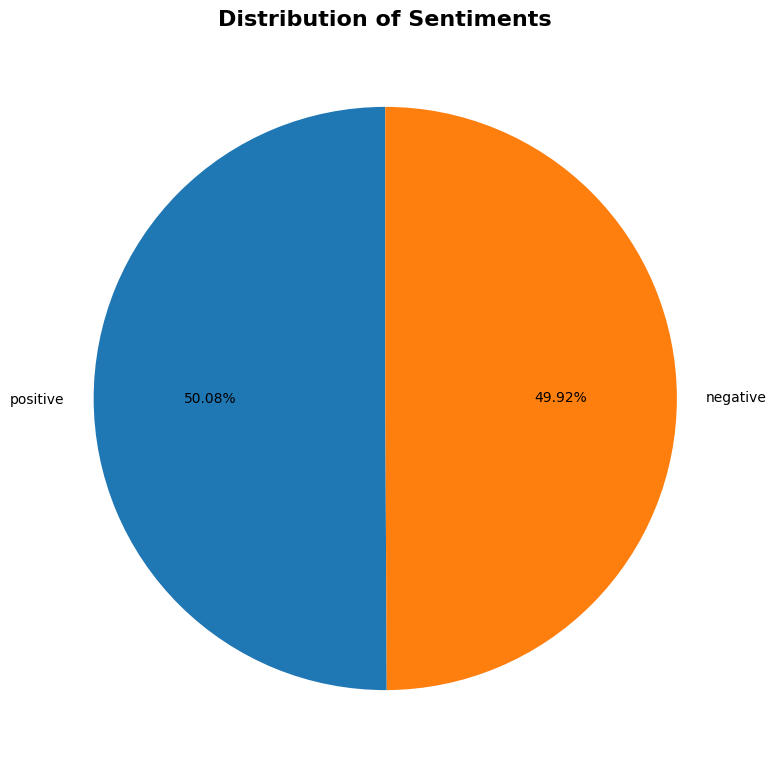

In [12]:
# see the table dataframe
print(df['label'].value_counts())

plt.figure(figsize = (8, 10)) # set figure size

# label mapping
# name label for pie chart later
actual_label = df['label'].value_counts().index.tolist()
name_label = []
for label in actual_label:
  if label == 0:
    name_label.append('positive') # if value 0 - positive sentiments
  else: name_label.append('negative') # if value 1 - negative sentiments

# pie chart of label column
plt.pie(
    df['label'].value_counts(), # the frequency data
    labels = name_label, # label for each slice of pie
    autopct = '%1.2f%%', # percentage format 2 number behind decimal
    startangle = 90 # start from 90 degrees
)

# set title
plt.title('Distribution of Sentiments', fontsize = 16, fontweight = 'bold')

plt.tight_layout()
plt.show()

By above results we can see there are **12472** reviews of **positive sentiments (values `0`)**, and there are **12432** reviews of **negative sentiments (values `1`)**. Even though not as perfectly balanced as original dataset (within 25000, there are 12500 of positives and negatives), these numbers still count as balanced dataset. So, we can use **accuracy** as metric evaluation in our modeling process later.

## iv.2. Distribution of Number of Words

To see the distribution of number of words, we will define new columns with value of number of words for each text in the column `text`. We will use `nltk.word_tokenize` for word tokenization to see the results. We will define new columns, first column `words` that is list of all words (tokens) by tokenizationm, and second column `word_count` that is number of words from column `words`.

In [13]:
# use nltk.word_tokenize for words
df['words'] = df['text'].apply(lambda x: nltk.word_tokenize(x)) # store list of all words - will be use on 3rd EDA
df['word_count'] = df['words'].apply(lambda x: len(x)) # # number of words

The skewness value for positive sentiments: 2.1379708260475776
The skewness value for negative sentiments: 2.161098198000051


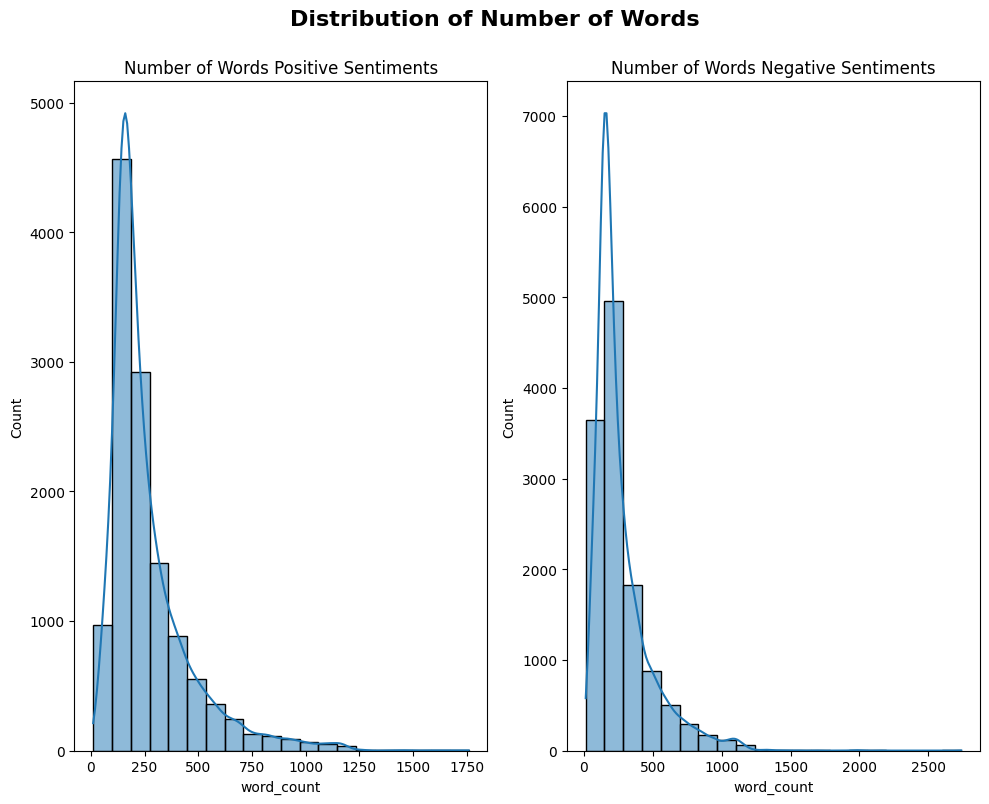

In [14]:
# create dataframe filtered positive and negative sentiments only
df_positive = df[df['label'] == 1]
df_negative = df[df['label'] == 0]

# calculate skewness value
print(f'The skewness value for positive sentiments: {df_positive['word_count'].skew()}')
print(f'The skewness value for negative sentiments: {df_negative['word_count'].skew()}')

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8)) # create figure 2x2

# plot the number of words for positive sentiments
sns.histplot(data=df_positive, x='word_count', bins=20, kde = True, ax=axes[0])
axes[0].set_title('Number of Words Positive Sentiments')

# plot the number of words for negative sentiments
sns.histplot(data=df_negative, x='word_count', bins=20, kde = True, ax=axes[1])
axes[1].set_title('Number of Words Negative Sentiments')

fig.suptitle('Distribution of Number of Words', fontsize = 16, fontweight = 'bold', y = 1)
plt.tight_layout()
plt.show()

In [15]:
# calculate max and average words on positive and negative sentiments
col = 'word_count'
df_positive_max_list = [df_positive[col].max()] # positive sentiments - max value
df_negative_max_list = [df_negative[col].max()] # negative sentiments - max value
df_positive_avg_list = [round(df_positive[col].mean(), 2)] # positive sentiments - avg value
df_negative_avg_list = [round(df_negative[col].mean(), 2)] # negative sentiments - avg value
df_avg_list = [round(df[col].mean(), 2)] # all sentiments - avg value

table_max_avg_positive_negative = pd.DataFrame({
    'Max Value - Positive Sentiments' : df_positive_max_list,
    'Max Value - Negative Sentiments' : df_negative_max_list,
    'Avg Value - Positive Sentiments' : df_positive_avg_list,
    'Avg Value - Negative Sentiments' : df_negative_avg_list,
    'Avg Value - All Sentiments' : df_avg_list
}, index = [col])

table_max_avg_positive_negative

,Max Value - Positive Sentiments,Max Value - Negative Sentiments,Avg Value - Positive Sentiments,Avg Value - Negative Sentiments,Avg Value - All Sentiments
word_count,1758,2738,265.33,270.75,268.04


By above results we can see that in this dataset, both positive and negative sentiments have average number of words 260-270's. While in whole document (without classify positive or negative sentiment only), the average is 268.04 still on the range 260 - 270. We can also see the maximum number of words for positive sentiments is 1758, while for negative sentiments the maximum number is 2738.

These results shows that number of words are same in average, for positive and negative sentiments, even whole document. But, the maximum number for negative higher than positive, indicates some negative sentiments can have more words of people arguing or show their disappointments. However, since the average are not differs many, perhaps in general are similar for positive and negative sentiments.

The visualization here still with the original text data that still has a lot of noise. In the modeling process, we will do preprocessing first to remove some noise such as capitalize word, punctuation, etc. This result only help for we to know number of words before the text data being preprocessed.

## iv.3. Frequent Words in Dataset -- Meaningful Sentiment Signals or Stop Words?

On the 2nd EDA earlier, we known number of words in the text data that still not preprocessed. We can see use the previous result of tokenization that stored on the column `words` earlier.

First, let we inspect the value of column `words` on first document (text data):

In [16]:
print(df['words'].iloc[0])

['For', 'a', 'movie', 'that', 'gets', 'no', 'respect', 'there', 'sure', 'are', 'a', 'lot', 'of', 'memorable', 'quotes', 'listed', 'for', 'this', 'gem', '.', 'Imagine', 'a', 'movie', 'where', 'Joe', 'Piscopo', 'is', 'actually', 'funny', '!', 'Maureen', 'Stapleton', 'is', 'a', 'scene', 'stealer', '.', 'The', 'Moroni', 'character', 'is', 'an', 'absolute', 'scream', '.', 'Watch', 'for', 'Alan', '``', 'The', 'Skipper', "''", 'Hale', 'jr.', 'as', 'a', 'police', 'Sgt', '.']


As expected, the result of `nltk.word_tokenize` earlier resulted in a list. If we combine all words for all document in the corpus (all texts in this dataset), then count each frequencies:

In [17]:
# define list for all words in the dataset
all_words = []

for words in df['words']: # loop for each words for each document (text data)
  for word in words: # loop for each word
    all_words.append(word)

# define dataframe to store all words earlier
words_df = pd.DataFrame({'word' : all_words})

In [18]:
# see the frequencies with value_counts method
# for example, we will see top 40 words
pd.set_option('display.max_columns', None) # for the values not truncated
pd.DataFrame(words_df['word'].value_counts()[:40]).T # to dataframe and transpose

word,the,",",.,and,a,of,to,is,in,I,it,that,'s,this,was,The,as,with,movie,for,film,),(,but,n't,``,'',on,you,are,not,have,his,be,he,!,one,at,by,all
count,288531,275126,272412,156021,155746,143296,133136,109032,86981,81260,77240,70097,61874,60509,49942,43876,43386,42760,42569,41862,38912,36100,35327,34951,33178,32937,32853,32538,30624,29919,28802,28171,27800,26458,24620,24210,23670,21723,21671,21240


Above result is top 40 words with most frequencies over all document in the corpus. All of these words are mostly **stopwords** which normally will be excluded on the preprocessing step. If we see list of stopwords from `nltk.corpus` that earlier imported to `stopwords`:

In [19]:
stop_words = sorted(set(stopwords.words('english')))
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Note that some of stopwords above are **important** for sentiment, that is to **differentiate between positive and negative sentiments**. However, as we seen on the frequent words earlier, some of stopwords still better to be removed since not carry significant meaning, even for sentiment analysis.

Some of stopwords that not needed: `the`, `and`, `a`, etc. On the other hand, there are also some of stopwords that still needed in sentiment such as: `no`, `not`, `isn't`, `haven't`, and other **negation words**, also `too`, `very`, `more`, and other **intense or exaggerate feeling words**, also `but` to show contrasts.

> **Source:** <br>
> - [don't-blindly-remove-stopwords-in-sentiment-analysis](https://dev.to/sunilaleti/don-t-blindly-remove-stopwords-in-sentiment-analysis-3nok)
> - [we-might-not-remove-the-stop-words](https://towardsdatascience.com/text-pre-processing-stop-words-removal-using-different-libraries-f20bac19929a/)

We can also note there are frequent words that **not in `stop_words`** but not needed in our case such as `film` and `movie`. This is because it is normal for many reviews to mention film and movie for reviews on IMDb platform. These words does not have meaning to differentiate between positive and negative sentiments.

We will handle this further in the **Feature Engineering** section upon preprocessing each document.

# v. Feature Engineering

## v.1. Text Preprocessing

As we note on the 3rd EDA, there are some stop words that not needed if we do tokenization right away, that is functional words such as `the`, `and`, `a`, `this`, `of`, `is`, etc. However, some of stop words are still needed because instead only act as functional words, some words also show sentiment signals:
- Negation words such as `no`, `nor`, `haven't`, `isn't`, `won't`, `weren't`, etc.
- Intensifier words such as `very`, `too`, `more`, `most`, and `so`
- Word that shows contrast: `but`

Note that list of negation words are too many, but we can handle this by **expand contractions** (`haven't` will be `have not` and `I'll` will be `I will`) to split negative contractions **before tokenization** process.
> Source: [nlp-expand-contractions](https://www.geeksforgeeks.org/nlp/nlp-expand-contractions-in-text-processing/)

In [20]:
# example text with negation contractions
text = "don't didn't doesn't hadn't hasn't haven't isn't wasn't weren't won't wouldn't shouldn't couldn't mustn't mightn't needn't shan't aren't"
# creating an empty list
expanded_words = []
for word in text.split():
  # using contractions.fix to expand the shortened words
  expanded_words.append(contractions.fix(word))
print(expanded_words)

['do not', 'did not', 'does not', 'had not', 'has not', 'have not', 'is not', 'was not', 'were not', 'will not', 'would not', 'should not', 'could not', 'must not', 'might not', 'need not', 'shall not', 'are not']


After that process, each negation words (that too many) will be left with words `have not`, `is not`, `will not`, `were not`, etc. Therefore, will be split by tokenization into words `have` and `not`, `is` and `not`, etc, that is functional words (`have`, `is`, etc) with `not`. This result means we only need to **exclude** `not` as representative of these negation words.

Therefore, if we do **expand contractions** before tokenization (which is after that remove stop words), if we list again the **words that need to exclude on remove stop words**:
- Negation words such as `no`, `nor`, and `not`
- Intensifier words such as `very`, `too`, `more`, `most`, and `so`
- Word that shows contrast: `but`

Also **words that need to include on remove stop words**: `film` and `movie` (and each of their plural form). For these findings, we will change the value of `stop_words` that earlier used:


In [21]:
new_stopwords = []

for word in stop_words:
  if word not in ['no', 'nor', 'not', 'very', 'too', 'more', 'most', 'so', 'but']: # if not words that give negative sentiment signals
    new_stopwords.append(word) # append to new list

# after looping add film and movie and their plural form
new_stopwords += ['film', 'movie', 'films', 'movies']
print(new_stopwords) # see the result

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she', "she'd", "she'll", "she's", 'should', "s

After above process, let we reconstruct steps to do for preprocessing steps:

1. Case Folding
2. Remove Numbers, Newline, URL, and Whitespaces
3. Expand Contractions
4. Remove Punctuation
5. Remove Non-letter (such as emoticon, symbol (like μ, $, 兀), etc)
6. Tokenization
7. Remove Stop Words
8. Stemming
9. Combining Tokens (into a single text)

The reason that the punctuation (and non-letter) removal after expand contractions because we need to expand negative contractions first such as `haven't`, `isn't`, `don't`, etc, before remove the colon `'`. We will construct these steps into a single function:

In [22]:
# define stemmer
stemmer = PorterStemmer()

In [23]:
# create a function for text preprocessing

def text_preprocessing(text):

  # 1. case folding
  text = text.lower()

  # 2. remove numbers, newline, URL, and whitespaces
  text = re.sub(r'\d+', '', text) # number removal
  text = re.sub(r"\\n", " ",text) # newline removal
  text = re.sub(r"http\S+", " ", text) # URL removal
  text = re.sub(r"www\.\S+", " ", text) # URL removal
  text = text.strip() # whitespace removal

  # 3. expand contractions
  text = contractions.fix(text)

  # 4. remove punctuations
  text = text.translate(str.maketrans('', '', string.punctuation))

  # 5. remove non-letter (such as emoticon, symbol (like μ, $, 兀), etc)
  text = re.sub(r"[^A-Za-z\s']", " ", text)

  # 6. tokenization
  tokens = word_tokenize(text)

  # 7. remove stop words
  tokens = [word for word in tokens if word not in new_stopwords] # use new_stopwords instead of stop_words

  # 8. stemming
  tokens = [stemmer.stem(word) for word in tokens] # use PorterStemmer earlier defined

  # 9. combining tokens into a single text as final step
  text = ' '.join(tokens)

  return text

After we defined the text preprocessing in above function, we will apply to the dataset:

In [24]:
df['text_processed'] = df['text'].apply(lambda x: text_preprocessing(x))

# see the result
df

,text,label,words,word_count,text_processed
0,For a movie that gets no respect there sure ar...,0,"[For, a, movie, that, gets, no, respect, there...",59,get no respect sure lot memor quot list gem im...
1,Bizarre horror movie filled with famous faces ...,0,"[Bizarre, horror, movie, filled, with, famous,...",204,bizarr horror fill famou face but stolen crist...
2,"A solid, if unremarkable film. Matthau, as Ein...",0,"[A, solid, ,, if, unremarkable, film, ., Matth...",64,solid unremark matthau einstein wonder favorit...
3,It's a strange feeling to sit alone in a theat...,0,"[It, 's, a, strange, feeling, to, sit, alone, ...",508,strang feel sit alon theater occupi parent rol...
4,"You probably all already know this by now, but...",0,"[You, probably, all, already, know, this, by, ...",169,probabl alreadi know but addit episod never ai...
...,...,...,...,...,...
24899,"My comments may be a bit of a spoiler, for wha...",1,"[My, comments, may, be, a, bit, of, a, spoiler...",198,comment may bit spoiler worth stop care enough...
24900,"The ""saucy"" misadventures of four au pairs who...",1,"[The, ``, saucy, '', misadventures, of, four, ...",483,sauci misadventur four au pair arriv london da...
24901,"Oh, those Italians! Assuming that movies about...",1,"[Oh, ,, those, Italians, !, Assuming, that, mo...",101,oh italian assum aristocrat weird fetish castl...
24902,Eight academy nominations? It's beyond belief....,1,"[Eight, academy, nominations, ?, It, 's, beyon...",488,eight academi nomin beyond belief think veri b...


By above result, we have done preprocessed each text (document) in the dataset (corpus). For further process, we will use this column `text_processed` instead of raw values column `text`.

## v.2. Data Splitting

We will split the data into train, validation, and test set. The test set will be act same behavior of unseen data, so will be used only on the final evaluation. While for training model, we will use train and validation set only.

In [25]:
# define seed for further process
seed = 35
os.environ['PYTHONHASHSEED'] = str(seed)

In [26]:
# data splitting
# use `text` column earlier
# then repeat the preprocessing step after that

# split train-val and test set for 85%:15%
X_train_val_ori, X_test_ori, y_train_val, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.15, # 15% test set size
    random_state=seed,
    stratify=df['label'] # so the proportion of label still the same
)
X_test = X_test_ori.apply(lambda x: text_preprocessing(x)) # apply preprocess text to the test set

# split train and val set for 90%:10%
X_train_ori, X_val_ori, y_train, y_val = train_test_split(
    X_train_val_ori,
    y_train_val,
    test_size=0.10, # 10% val set size
    random_state=seed,
    stratify=y_train_val # so the proportion of label still the same
)
X_train = X_train_ori.apply(lambda x: text_preprocessing(x)) # apply preprocess text to the train set
X_val = X_val_ori.apply(lambda x: text_preprocessing(x)) # apply preprocess text to the val set

print(f'Train Size : {X_train.shape}')
print(f'Val Size   : {X_val.shape}')
print(f'Test Size  : {X_test.shape}')

Train Size : (19051,)
Val Size   : (2117,)
Test Size  : (3736,)


# vi. ANN Training

## vi.1. Model Definition

The objective of this project is to perform **sentiment analysis** on review data on IMDb platform. Since the target variable has two classes (positive and negative sentiments), this is **a supervised binary classification task** within the field of **Natural Language Processing (NLP)**.

To model sequential text data, in this project we will use **Long Short-Term Memory (LSTM)** network, that is a variant of Recurrent Neural Network (RNN) under the Artificial Neural Network (ANN) framework. LSTM which is a type of RNN that is able to keep track of long-term dependencies in sequential data, unlike classic machine learning algorithms, which makes LSTM suitable for text classification problems.

The input text is previously preprocessed so that the text will be used in the model already out of noise. The resulting preprocessed text is considered as sequences that are later passed through **text vectorization** and **embedding layer** before LSTM layers learn dependencies of each text.

Additionally, earlier we know that the dataset is balanced between positive and negative sentiments. Hence, for model performance evaluation we will use **Accuracy** as metric for evaluation.

### vi.1.1. Text Vectorization for Model Building

First, we will calculate number of vocabulary with `CountVectorizer`, kindly take a note that we will not use the result of vectorization with `CountVectorizer` for further process:
> Note that, we will not use `CountVectorizer` for further modeling process, because the model that will be developed in this project is using ANN framework

In [27]:
# get vocabularies
Vectorizer = CountVectorizer()
_ = Vectorizer.fit_transform(X_train)
_ = Vectorizer.transform(X_test)

# find number of vocabs and max token length in one document
total_vocab = len(Vectorizer.vocabulary_.keys())
max_sen_len = max([len(i.split(" ")) for i in X_train])

print('Total Vocab : ', total_vocab)
print('Maximum Sentence Length : ', max_sen_len, 'tokens')

Total Vocab :  68469
Maximum Sentence Length :  1476 tokens


After we have total vocab, we will use this as parameter `max_tokens` for `TextVectorization` that later will be used as first layer of our model from the preprocessed text as input:

In [28]:
# text vectorization
text_vectorization = TextVectorization(
    max_tokens=total_vocab, # use all vocab as max tokens
    standardize="lower_and_strip_punctuation", # case folding and remove punctuation for standardize
    split="whitespace",
    ngrams=None,
    output_mode="int", # since only act as first layer, that will be used again later
    output_sequence_length=max_sen_len, # use maximum sentence length as output sequence
    input_shape=(1,) # input shape 1 dimension document
)

# adapt process
text_vectorization.adapt(X_train)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/text_vectorization.py:340: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(name=name, **kwargs)
I0000 00:00:1777341780.323467      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777341780.329851      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


By above result, first layer for model that is `TextVectorization` that will use preprocessed text as input already defined and adapted with train set. For example result:

In [29]:
# example result

## document example
print('Document example')
print(df['text_processed'][0], '\n') # first document in corpus (first text in dataset)

## result of Text Vectorization
print('Result of Text Vectorization')
print(text_vectorization([df['text_processed'][0]]))
print(f"Vector size : {text_vectorization([df['text_processed'][0]]).shape}\n")

# view the Top 20 Tokens (sorted by the highest frequency of appearance)
text_vectorization.get_vocabulary()[:20]

Document example
get no respect sure lot memor quot list gem imagin joe piscopo actual funni maureen stapleton scene stealer moroni charact absolut scream watch alan skipper hale jr polic sgt 

Result of Text Vectorization
tf.Tensor([[ 13  19 614 ...   0   0   0]], shape=(1, 1476), dtype=int64)
Vector size : (1, 1476)



['',
 '[UNK]',
 np.str_('not'),
 np.str_('but'),
 np.str_('one'),
 np.str_('like'),
 np.str_('so'),
 np.str_('would'),
 np.str_('time'),
 np.str_('good'),
 np.str_('make'),
 np.str_('more'),
 np.str_('veri'),
 np.str_('get'),
 np.str_('charact'),
 np.str_('see'),
 np.str_('watch'),
 np.str_('even'),
 np.str_('stori'),
 np.str_('no')]

For example, this first documnent is vectorized into sequence of **1476 tokens** by defined text vectorization. Top vocabulary first is `not` and `but` because we exclude this when stop words removal earlier.

This result after vectorization on first layer, the output will be act as input of next layer that is **Embedding** layer.

### vi.1.2. Word Embedding for Model Building

After text vectorization, before LSTM layers, we need **embedding layer** as a second layer in our model:

In [30]:
# define embedding
embedding = Embedding(
    input_dim=total_vocab, # use all vocab earlier
    output_dim=128, # dimension vector output for each tokens
    embeddings_initializer="uniform", # initial weights uniform
    input_length=max_sen_len # use maximum sentence length earlier
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


By above process, second layer for model that is `Embedding` for word embedding, already defined. For example result:

In [31]:
# example result

## document example
print('Document example')
print(df['text_processed'][0], '\n') # first document in corpus (first text in dataset)

## result of text vectorization
print('Result of Text Vectorization')
print(text_vectorization([df['text_processed'][0]]))
print(f"Vector size : {text_vectorization([df['text_processed'][0]]).shape}\n")

## result of  embedding
print('Result of  Embedding')
print(embedding(text_vectorization([df['text_processed'][0]])))
print(f"Vector size : {embedding(text_vectorization([df['text_processed'][0]])).shape}")

Document example
get no respect sure lot memor quot list gem imagin joe piscopo actual funni maureen stapleton scene stealer moroni charact absolut scream watch alan skipper hale jr polic sgt 

Result of Text Vectorization
tf.Tensor([[ 13  19 614 ...   0   0   0]], shape=(1, 1476), dtype=int64)
Vector size : (1, 1476)

Result of  Embedding
tf.Tensor(
[[[-0.04616899 -0.04171928  0.0436591  ... -0.00383864 -0.01389259
    0.01142312]
  [ 0.01829034  0.02079176 -0.03919015 ... -0.01901045 -0.00916762
    0.03928867]
  [-0.01923373 -0.01265765 -0.02069607 ...  0.00090348  0.00831517
    0.00278864]
  ...
  [ 0.04169977 -0.04823446 -0.00304332 ... -0.02909569 -0.00974271
   -0.02583977]
  [ 0.04169977 -0.04823446 -0.00304332 ... -0.02909569 -0.00974271
   -0.02583977]
  [ 0.04169977 -0.04823446 -0.00304332 ... -0.02909569 -0.00974271
   -0.02583977]]], shape=(1, 1476, 128), dtype=float32)
Vector size : (1, 1476, 128)


By above results, the embedding result of first document have vector with dimension size (1 x 1476 x 128) that comes from 1476 tokens as input of embedding layer after process on text vectorization on first layer.

### vi.1.3. First Model Definition with LSTM

Next, we will define the architecture of ANN model along with text vectorization earlier and word embedding that defined earlier:

> **Reference how same results for each run**:
> - [primer-on-developing-reproducible-neural-networks-in-jupyter-notebook](https://towardsdatascience.com/primer-on-developing-reproducible-neural-networks-in-jupyter-notebook-2f88d23b7c8d)
> - [configures-tensorflow-to-run-deterministically](https://www.tensorflow.org/api_docs/python/tf/config/experimental/enable_op_determinism)
> - [how-to-get-reproducible-results-in-keras](https://stackoverflow.com/questions/32419510/how-to-get-reproducible-results-in-keras/52897216#52897216)

> Above references are the reason we need to set following codes:
```
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.config.experimental.enable_op_determinism()
```

In [32]:
# model definition with LSTM

## clear session
## use seed defined above on section v.2. Data Splitting
tf.keras.backend.clear_session()
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.config.experimental.enable_op_determinism()

## redefine the `embedding` earlier with seed
embedding = Embedding(
    input_dim=total_vocab, # use all vocab earlier
    output_dim=128, # dimension vector output for each tokens
    embeddings_initializer=tf.keras.initializers.RandomUniform(seed=seed), # uniform initial weights with seed
    input_length=max_sen_len # use maximum sentence length earlier
)

## Define the architecture - Sequential API
model_lstm_1 = Sequential()
model_lstm_1.add(InputLayer(input_shape=(1,), dtype=tf.string))
model_lstm_1.add(text_vectorization)

## embedding layer with seed
model_lstm_1.add(embedding)

## first LSTM layer
model_lstm_1.add(Bidirectional(LSTM(32, return_sequences=True, # set True because there is another LSTM layer after this
                                    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed), # kernel initializer with seed
                                    recurrent_initializer=tf.keras.initializers.Orthogonal(seed=seed)))) # recurrent initializer with seed
model_lstm_1.add(Dropout(0.1, seed=seed))

## second LSTM layer
model_lstm_1.add(Bidirectional(LSTM(16,
                                    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed), # kernel initializer with seed
                                    recurrent_initializer=tf.keras.initializers.Orthogonal(seed=seed)))) # recurrent initializer with seed
model_lstm_1.add(Dropout(0.1, seed=seed))

## last layer
model_lstm_1.add(Dense(1, activation='sigmoid',
                       kernel_initializer=tf.keras.initializers.GlorotNormal(seed=seed))) # kernel initializer with seed

model_lstm_1.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy'] # use accuracy as metric evaluation -- we will use default threshold
)

model_lstm_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 1476)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 1476, 128)      │     8,764,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1476, 64)       │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1476, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,815,649 (33.63 MB)

 Trainable params: 8,815,649 (33.63 MB)

 Non-trainable params: 0 (0.00 B)

First model created on above code is firstly use `TextVectorization` earlier defined and for each vector created by each input document is embedded with `Embedding` earlier defined. The resulted vector after these 2 layers is vector with dimension `(1 x 1476 x 128)`, which the embedding layers have `(128 x 68469)` parameter resulted from total vocab that being used is total vocab from document earlier defined.

Next layer after that is **first LSTM layer** which defined with `Bidirectional` with 32 neurons (resulted 64 because bidirectional), which its output use **regularization dropout 10%**. Layer after that use **second LSTM layer** again `Bidirectional` with 16 neuros (resulted 32) which use dropout 10% for the output. Note that for both LSTM layer uses **GlorotUniform kernel initializer** to improve weight initialization so the model can learn more effective during training.

After that, the final output is only one output with **sigmoid activation function** following our primary objective, that is binary classification. The compiler we use is `binary_crossentropy` because binary classification, use metrics `accuracy`, and optimizer `adam`. This model will be first basic model that we use for first training in this project.

If we see the layer plot as below:

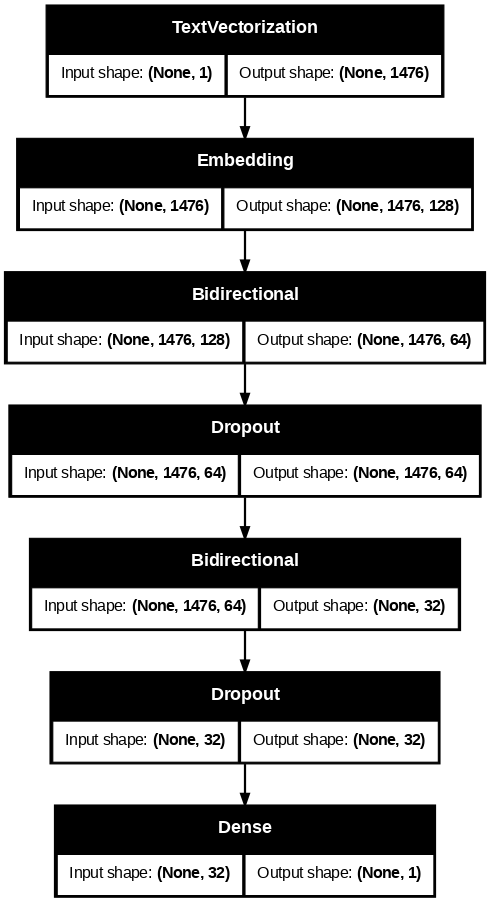

In [33]:
# plot layers

tf.keras.utils.plot_model(model_lstm_1, show_shapes=True, dpi=80)

## vi.2. Model Training

The defined model above, we will perform the training **without limiting the `epochs`** (i.e. use `callbacks`), for example we use 30 `epochs`, the result is as below:

In [34]:
# model training

# generate batch dataset
X_train_array = np.array(X_train, dtype=str)
X_val_array = np.array(X_val, dtype=str)
batch_size = 32 # use 32 batch size that usually default value

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_array, y_train)).batch(batch_size)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_array, y_val)).batch(batch_size)

# training
start = time.perf_counter() # time start
model_lstm_1_hist = model_lstm_1.fit(train_dataset, validation_data=val_dataset, epochs=30) # will do 30 epochs
end = time.perf_counter() # time ends
print(f"Training time: {end - start:.2f} seconds")

Epoch 1/30


I0000 00:00:1777341791.007481     145 cuda_dnn.cc:529] Loaded cuDNN version 91002


596/596 ━━━━━━━━━━━━━━━━━━━━ 126s 201ms/step - accuracy: 0.7359 - loss: 0.5026 - val_accuracy: 0.8772 - val_loss: 0.3116
Epoch 2/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 119s 200ms/step - accuracy: 0.9159 - loss: 0.2247 - val_accuracy: 0.8517 - val_loss: 0.4436
Epoch 3/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 120s 201ms/step - accuracy: 0.9537 - loss: 0.1350 - val_accuracy: 0.8545 - val_loss: 0.4529
Epoch 4/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 119s 200ms/step - accuracy: 0.9761 - loss: 0.0824 - val_accuracy: 0.8432 - val_loss: 0.5982
Epoch 5/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 120s 201ms/step - accuracy: 0.9819 - loss: 0.0626 - val_accuracy: 0.8229 - val_loss: 0.5653
Epoch 6/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 119s 199ms/step - accuracy: 0.9416 - loss: 0.1628 - val_accuracy: 0.8540 - val_loss: 0.4232
Epoch 7/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 119s 199ms/step - accuracy: 0.9707 - loss: 0.0876 - val_accuracy: 0.8488 - val_loss: 0.4741
Epoch 8/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 119s 200ms/step - accuracy: 0.9838 - loss: 0.05

By the values above, we can see the final result loss on validation set is still high compare to loss on training set. This result also affected to the accuracy which is our primary objective for evaluation. We will evaluate further by see the result of this historical training data of this model, on the the plot in the next section.

## vi.3. Model Evaluation

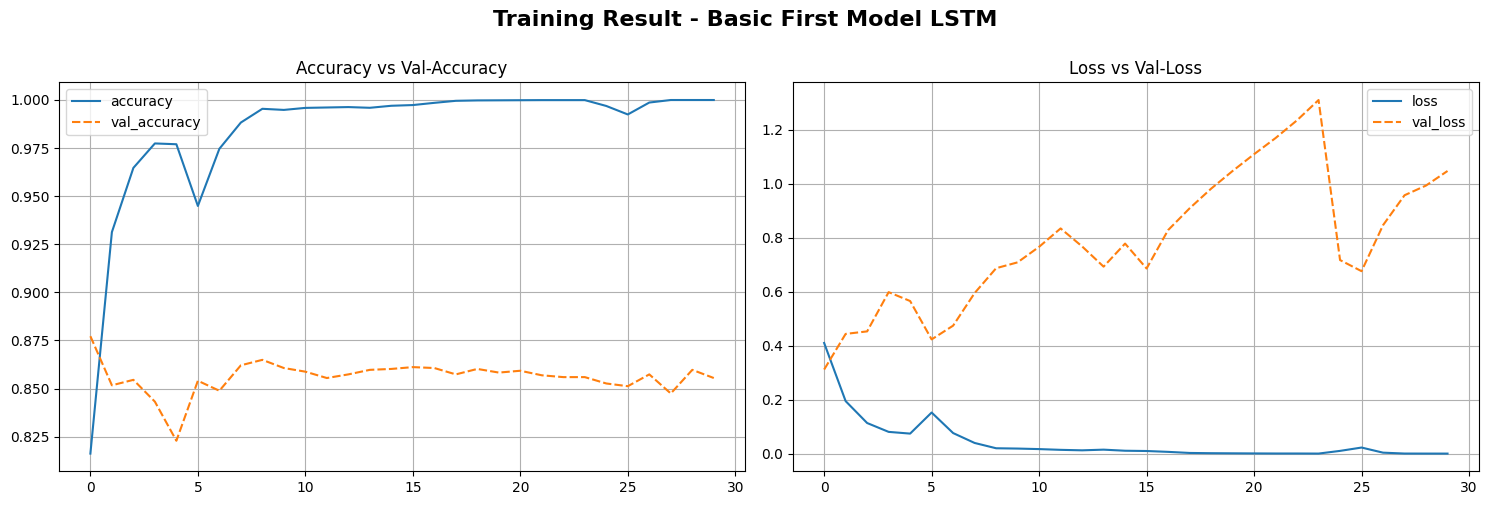

In [35]:
# plot training results

model_lstm_1_hist_df = pd.DataFrame(model_lstm_1_hist.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=model_lstm_1_hist_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')

plt.subplot(1, 2, 2)
sns.lineplot(data=model_lstm_1_hist_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

# set overall title
plt.suptitle('Training Result - Basic First Model LSTM', fontsize = 16, fontweight = 'bold', y = 1)
plt.tight_layout()
plt.show()

By above plot we can see the model is overfitting because the gap between train and validation set performance are too distant. This overfitting occurred even on the first epoch until 30 epochs. This may happen because no callbacks such as **EarlyStopping**. Also perhaps due to the model are too complex, which earlier mentioned have 8,815,649 parameters and size 33.63 MB.

Additionally, since we still in the state to compare between models, there are no need to evaluate on the test set for now. To prevent **overfit to the test set**, we will compare the result of this first model with later improvement model on the **train and validation set only**.

> **Additional Note:** <br>
> Next step is training process of redefined of this first model with less complex model but still train model from scratch and without using callbacks. The key is to show that need different approach rather than try all combination of the current way

### vi.3.1 Redefine Model with Lower Complexity

Earlier, we suggests that perhaps because of the previous ANN model is too complex means due to many layers and many parameters (also comes from embedding layer parameters and vectorization way) that defined on previous model. If we **try to lower complexity** this model:
> Note that, we still not use callbacks and transfer learning (still train model from scratch) to compare is lower complexity of previous model can result better or not

In [36]:
## clear session
## use seed defined above on section v.2. Data Splitting
tf.keras.backend.clear_session()
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.config.experimental.enable_op_determinism()


# redefine text vectorization
text_vectorization_2 = TextVectorization(
    max_tokens=10000, # use 10,000 as max tokens instead of total vocab (68,469)
    standardize="lower_and_strip_punctuation", # case folding and remove punctuation for standardize
    split="whitespace",
    ngrams=None,
    output_mode="int", # since only act as first layer, that will be used again later
    output_sequence_length=80, # use lower than average tokens as output sequence
    input_shape=(1,) # input shape 1 dimension document
)

# adapt process
text_vectorization_2.adapt(X_train)

# redefine embedding
embedding_2 = Embedding(
    input_dim=text_vectorization_2.vocabulary_size(), # use the result from text vectorization
    output_dim=128, # dimension vector output for each tokens -- same as before
    embeddings_initializer=tf.keras.initializers.RandomUniform(seed=seed), # uniform initial weights with seed
    input_length=80 # use 80 same as text vectorization
)

# redefine model

## Define the architecture - Sequential API
model_lstm_2 = Sequential()
model_lstm_2.add(InputLayer(input_shape=(1,), dtype=tf.string))
model_lstm_2.add(text_vectorization_2) # use new text vectorization

## embedding layer with seed
model_lstm_2.add(embedding_2) # use new embedding that less complexity

## After new text vectorization and new embedding, the rest are similar as previous model - with changes only 1 layer LSTM and only 16 neuron
## first LSTM layer
model_lstm_2.add(Bidirectional(LSTM(16,
                                    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed), # kernel initializer with seed
                                    recurrent_initializer=tf.keras.initializers.Orthogonal(seed=seed)))) # recurrent initializer with seed
model_lstm_2.add(Dropout(0.3, seed=seed)) # more percentage of dropout -- more regularization

## last layer
model_lstm_2.add(Dense(1, activation='sigmoid',
                       kernel_initializer=tf.keras.initializers.GlorotNormal(seed=seed))) # kernel initializer with seed

model_lstm_2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy'] # use accuracy as metric evaluation -- we will use default threshold
)

model_lstm_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/text_vectorization.py:340: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(name=name, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 80)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 80, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32)             │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,298,593 (4.95 MB)

 Trainable params: 1,298,593 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6950 - loss: 0.5549 - val_accuracy: 0.8569 - val_loss: 0.3530
Epoch 2/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8835 - loss: 0.2949 - val_accuracy: 0.8399 - val_loss: 0.3873
Epoch 3/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9243 - loss: 0.2008 - val_accuracy: 0.8408 - val_loss: 0.4505
Epoch 4/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9498 - loss: 0.1428 - val_accuracy: 0.8347 - val_loss: 0.5133
Epoch 5/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9670 - loss: 0.0990 - val_accuracy: 0.8243 - val_loss: 0.6339
Epoch 6/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9731 - loss: 0.0819 - val_accuracy: 0.8304 - val_loss: 0.5958
Epoch 7/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9796 - loss: 0.0609 - val_accuracy: 0.8347 - val_loss: 0.6121
Epoch 8/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9891 - loss: 0.0378 - val_accu

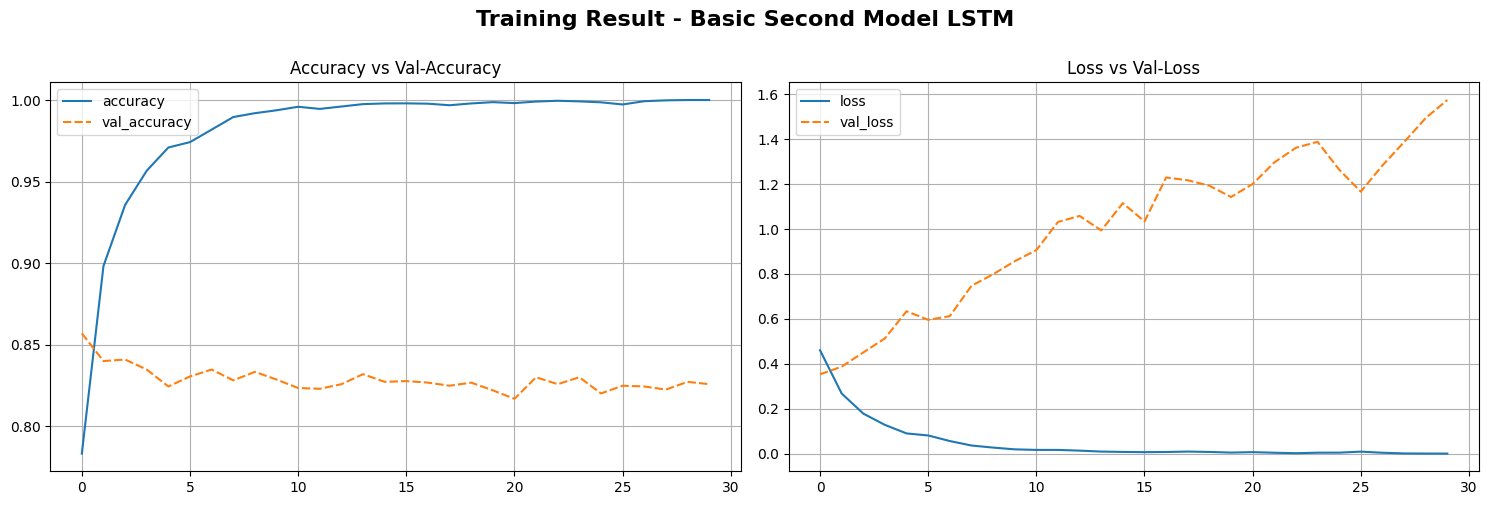

In [37]:
# model training

# generate batch dataset
X_train_array = np.array(X_train, dtype=str)
X_val_array = np.array(X_val, dtype=str)
batch_size = 32 # use 32 batch size that usually default value

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_array, y_train)).batch(batch_size)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_array, y_val)).batch(batch_size)

# training
start = time.perf_counter() # time start
model_lstm_2_hist = model_lstm_2.fit(train_dataset, validation_data=val_dataset, epochs=30) # will do 30 epochs
end = time.perf_counter() # time ends
print(f"Training time: {end - start:.2f} seconds")

# plot training results

model_lstm_2_hist_df = pd.DataFrame(model_lstm_2_hist.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=model_lstm_2_hist_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')

plt.subplot(1, 2, 2)
sns.lineplot(data=model_lstm_2_hist_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

# set overall title
plt.suptitle('Training Result - Basic Second Model LSTM', fontsize = 16, fontweight = 'bold', y = 1)
plt.tight_layout()
plt.show()

Note that, even after less complexity of first model creation, this second model still resulting in **overfitting** tendency the more epochs learning process. Perhaps **stopping this overfitting tendency** may really needed for next improvement model. Another thing is we should take a note that the model also train poorly perhaps due to **training model from scratch** because we do training to the Embedding layer as well that still have many parameters. We need to overcome both of these lacking from the first and second model for next model improvement.

For the next model improvement, we will try to increase the performance by try to **stop this overfitting behavior** with `EarlyStopping`. Also we will try to use **transfer learning** method by use pretrained model for **Embedding layer**.

Same as previous, since we still in the state to compare between models, there are no need to evaluate on the test set for now. To prevent **overfit to the test set**, we will compare the result of these first and second model on this **ANN Training** section with later improvement model in **ANN Improvement** section, by comparison on the **train and validation set only**.

# vii. ANN Improvement

## vii.1 Model Definition

On the improvement model (third model), we want **improvement** of our first model (and second model) that training from scratch, especially on its embedding layer. In this improvement model we will use **transfer learning** with Word2Vec pre-trained word embeddings, later for embedding layer as pre-trained model.

Metric that will be used for model evaluation, again is **accuracy**, to later compare with earlier models (first and second model) defined on previous section **ANN Training**. Since previously we encountered the **overfitting tendedncy** problem, because the model are trained with many epochs, we will use **EarlyStopping callbacks** here, to prevent this. So, before overfitting get worsen, the training process is stop, and we able to retrieve the **best weights** of all training epochs.

On the later section, after comparison with earlier models (first and second model), we will choose the better one. The chosen model will be the final model, to be used for evaluation on the **test set** as representative of unseen dataset. Therefore, such final model will also be used for future inference and model deployment.

### vii.1.1 Transfer Learning with Word2Vec

Note that, on the first model we use `TextVectorization` and `Embedding` that need to training from zero. Since Word2Vec need input tokenized document, we will do manual tokenization process with `nltk.word_tokenize` from **nltk** and `Tokenizer` from **keras**.

In [38]:
# different vectorization approach
# now do not use TextVectorization

## tokenization
X_train_vec = [nltk.word_tokenize(text) for text in X_train]
X_val_vec = [nltk.word_tokenize(text) for text in X_val]
X_test_vec = [nltk.word_tokenize(text) for text in X_test]

# new embedding use Word2Vec
# since we already generated word vectors using gensim's word2vec, we will load these pre-trained vectors into Embedding layer
# and set this Embedding layer non-trainable, to utilize the pre-trained word vectors in the model without modifying further

# next process is training word2vec from sentences -- tokens from our data
EMBEDDING_DIM = 100 # dimension of vectors we are generating
w2v_model = Word2Vec(sentences=X_train_vec, vector_size=EMBEDDING_DIM, window=5, min_count=1, # creating word vectors by Word2Vec method use train set tokens
                     seed=seed, workers=1) # use same seed as defined and workers=1 for deterministic

> **Reference**: [how-to-get-same-word2vec-vectors-in-every-time-of-training](https://pub.towardsai.net/how-to-get-same-word2vec-doc2vec-paragraph-vectors-in-every-time-of-training-335bac809c83)

After above process, the defined model `w2v_model` is predefined Word2Vec that use `sentences` from `X_train_vec` that is list of words (tokens) from traini set. Next process is tokenization from texts to sequences and **padding sequences** of these list of words.

### vii.1.2 Checking Average Words in Train Set for Padding Sequences

First, we will see distribution of number of words by repeat the process that we done on second EDA. However, for this process for modeling we will not separate between positive and negative sentiments, instead we will use train set that contains both type of sentiments:

In [39]:
# to dataframe first only to see on the train set
# this is what will be used in this step, further process still use X_train
X_train_df = pd.DataFrame(X_train) # use to calculate number of words same as on EDA

# use nltk.word_tokenize for words
X_train_df['word_count'] = X_train_df['text'].apply(lambda x: len(nltk.word_tokenize(x))) # number of words
col = 'word_count'

## calculate skewness value
skew = X_train_df[col].skew()
print(f'The skewness value: {skew}')

The skewness value: 2.242691425603672


Since the skewness > 1, that means the distribution is **extremely positive skew** we will find upper boundary of outlier and distribution number of words:

The upper boundary of outlier: (401.0)



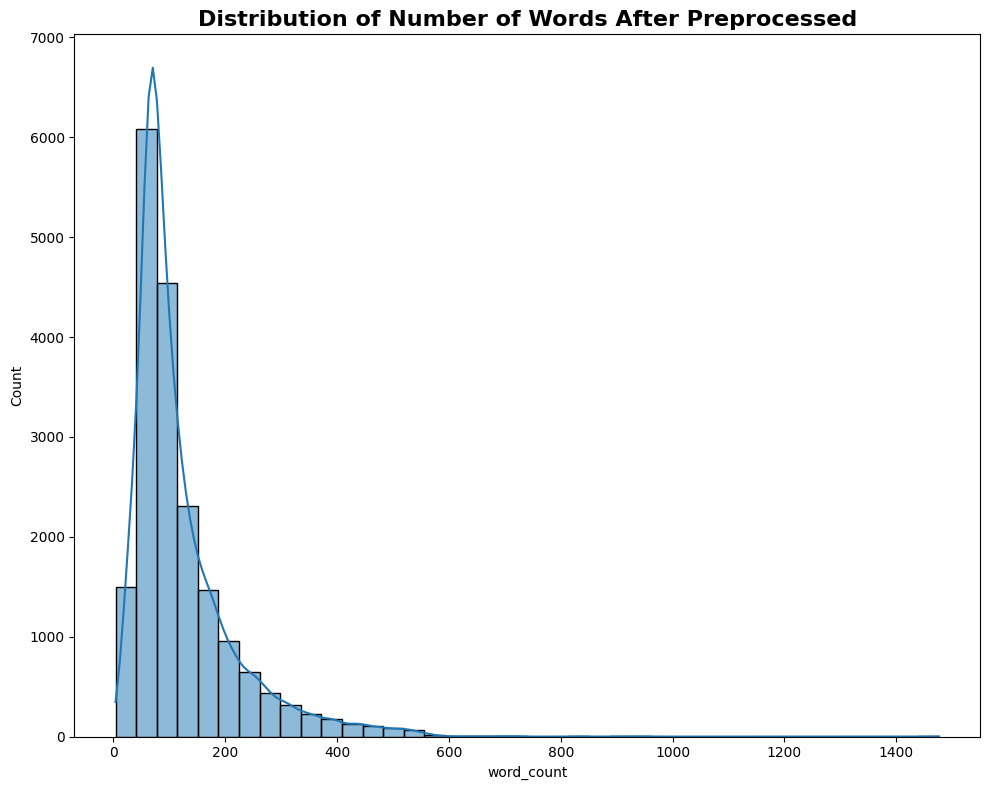

,Max Value,Avg Value
word_count,1476,121.784053


In [40]:
## see upper boundary of outlier based on skewness
fold = 3 # use 3 since extremely skewed

iqr = X_train_df[col].quantile(0.75) - X_train_df[col].quantile(0.25)
up_bound = X_train_df[col].quantile(0.75) + (fold * iqr) # based on fold
print(f'The upper boundary of outlier: ({up_bound})')
print() # to separate line


## plot histogram
plt.figure(figsize=(10, 8)) # set figure size
sns.histplot(data=X_train_df, x=col, bins=40, kde = True)
plt.title('Distribution of Number of Words After Preprocessed', fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()


## calculate max and average words to see in table dataframe
X_train_df_max_list = [X_train_df[col].max()] # max value
X_train_df_avg_list = [X_train_df[col].mean()] # avg value

table_max_avg_train = pd.DataFrame({
    'Max Value' : X_train_df_max_list,
    'Avg Value' : X_train_df_avg_list
}, index = [col])

table_max_avg_train

By above result we can see that in average there are 121 words for each document in the train set. Also the upper boundary for outliers are 401 words, more than this counted as outliers. This result means that earlier maximum sentence length we are used on first model is **too many** for most of document, because we use the maximum one, that is 1476 tokens (words).

For this improvement model, we will use **200 for maximum tokens** on **padding** as below:

In [41]:
# define tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_vec)

# convert tokens from previous tokenized document into sequences of integers
X_train_vec = tokenizer.texts_to_sequences(X_train_vec)
X_val_vec = tokenizer.texts_to_sequences(X_val_vec)
X_test_vec = tokenizer.texts_to_sequences(X_test_vec)

# padding sequences 200 as chosen
X_train_vec = pad_sequences(X_train_vec, maxlen=200)
X_val_vec = pad_sequences(X_val_vec, maxlen=200)
X_test_vec = pad_sequences(X_test_vec, maxlen=200)

Note that, by above result all documents that already tokenized (earlier with `_vec` name), then converted to sequences of integers (vectorized) and each sequences have been padding. This is the same as `TextVectorization` earlier. However, this manual way is because Word2Vec need tokenized sentences (list of words) instead of raw string (each document) input.

### vii.1.3 Embedding Matrix from Word2Vec for Embedding Layer

Recall that earlier Word2vec defined to `w2v_model` that use tokenized train set to get the word vectors. After previous process, we will get embedding matrix from Word2Vec and will be using it as weights of non-trainable keras embeddling layer later:

In [42]:
# define vocab size
# adding 1 because of reserved 0 index
# embedding Layer creates one more vector for "UNKNOWN" words, or padded words (0s). this vector is filled with zeros.
# thus our vocab size increases by 1
vocab_size = len(tokenizer.word_index) + 1

# define function to be used for getting embedding vectors from word2vec and using it as weights of non-trainable keras embedding layer
def get_weight_matrix(model, vocab):
    # Get embedding dimension from the model
    embedding_dim = model.wv.vector_size

    # Initialize the weight matrix with zeros
    weight_matrix = np.zeros((len(vocab) + 1, embedding_dim))

    # Iterate over the vocabulary, store vectors using the Tokenizer's integer mapping
    for word, i in vocab.items():
        if word in model.wv:
            weight_matrix[i] = model.wv.get_vector(word)

    return weight_matrix

# use function above
word_index = tokenizer.word_index
embedding_vectors = get_weight_matrix(w2v_model, word_index)

Finally, we can define embedding layer with embedding vectors from Word2Vec and set **non-trainable** as the **pre-trained model** for this improvement model. We will define later along with other layers on the next section.

### vii.1.4 Improvement Model Definition with LSTM

After defined embedding layer from Word2Vec earlier, we will define architecture of second ANN model with **Embedding Layer as first layer** because we will use **vectorized document** (sequences of integers) as input for this improvement model (vectorized train set `X_train_vec` earlier). The next layers, each hyperparameter, and optimizer are the same with first model. Also, we will use accuracy for metric evaluation later.

In [43]:
# third model definition with LSTM

## clear session
## use seed defined above on section v.2. Data Splitting
tf.keras.backend.clear_session()
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.config.experimental.enable_op_determinism()

## define embedding
embedding_3 = Embedding(
    input_dim=vocab_size, # use defined vocab_size earlier
    output_dim=EMBEDDING_DIM, # use 100 embedding dim
    weights=[embedding_vectors], # use embedding vectors from word2vec (non-trainable)
    input_length=200, # use padding size earlier
    trainable=False  # freeze from pretrained model
)

## Define the architecture - Sequential API
## now, we do not input textvectorization because tokenization already done assigned on X_train_vec
model_lstm_3 = Sequential()
model_lstm_3.add(InputLayer(input_shape=(200,))) # since already padded 200
model_lstm_3.add(embedding_3) # use new embedding from transfer learning

# first layer LSTM
model_lstm_3.add(Bidirectional(LSTM(32, return_sequences=True, # set True because there is another LSTM layer after this
                                    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed), # kernel initializer with seed
                                    recurrent_initializer=tf.keras.initializers.Orthogonal(seed=seed)))) # recurrent initializer with seed
model_lstm_3.add(Dropout(0.2, seed=seed))

# second layer LSTM
model_lstm_3.add(Bidirectional(LSTM(16,
                                    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed), # kernel initializer with seed
                                    recurrent_initializer=tf.keras.initializers.Orthogonal(seed=seed)))) # recurrent initializer with seed
model_lstm_3.add(Dropout(0.2, seed=seed))

## last layer
model_lstm_3.add(Dense(1, activation='sigmoid',
                       kernel_initializer=tf.keras.initializers.GlorotNormal(seed=seed))) # kernel initializer with seed

model_lstm_3.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy'] # use accuracy as metric evaluation -- we will use default threshold
)

model_lstm_3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │     6,848,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 64)        │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,893,349 (26.30 MB)

 Trainable params: 44,449 (173.63 KB)

 Non-trainable params: 6,848,900 (26.13 MB)

Note that there are **6,848,900 non-trainable parameters** on this improvement model. These parameters are come from the embedding matrix from Word2Vec vectors, that is our pre-trained model **Embedding layer with Word2Vec** for this model. The embedding weights are frozen and will not be updated during training proocess of this improvement model.

If we see the layer plot as below:

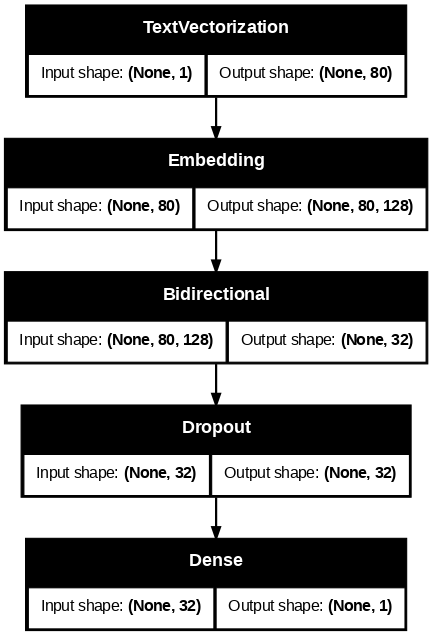

In [44]:
# plot layers

tf.keras.utils.plot_model(model_lstm_2, show_shapes=True, dpi=80)

## vii.2. Model Training

Other than we used pre-trained model, we will also **prevent overfitting** in this improvement model with `EarlyStopping` by setting `callbacks` upon training. We will still defined 30 `epochs` for training process, but the process may be stopped by this `callbacks`:

In [45]:
# model training

# define early stopping for callbacks to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', # monitor val_loss
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=5, # number of epochs to wait before stopping
    restore_best_weights=True,
)

# generate batch dataset
# now use X_train_vec and X_val_vec
X_train_array = np.array(X_train_vec, dtype='int32') # now X_train_vec already vectorized -- sequences of integers
X_val_array = np.array(X_val_vec, dtype='int32') # now X_test_vec already vectorized -- sequences of integers
batch_size = 32 # use 32 batch size that usually default value

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_array, y_train)).batch(batch_size)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_array, y_val)).batch(batch_size)

# training
start = time.perf_counter() # time start
model_lstm_3_hist = model_lstm_3.fit(train_dataset, validation_data=val_dataset, epochs=30, # will do 30 epochs
                                     callbacks=[early_stopping]) # but use callbacks
end = time.perf_counter() # time ends
print(f"Training time: {end - start:.2f} seconds")

Epoch 1/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.7454 - loss: 0.5151 - val_accuracy: 0.8375 - val_loss: 0.3801
Epoch 2/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.8102 - loss: 0.4190 - val_accuracy: 0.8493 - val_loss: 0.3437
Epoch 3/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.8495 - loss: 0.3508 - val_accuracy: 0.8583 - val_loss: 0.3260
Epoch 4/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.8611 - loss: 0.3261 - val_accuracy: 0.8583 - val_loss: 0.3184
Epoch 5/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.8725 - loss: 0.3073 - val_accuracy: 0.8621 - val_loss: 0.3058
Epoch 6/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.8776 - loss: 0.2928 - val_accuracy: 0.8644 - val_loss: 0.3085
Epoch 7/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.8841 - loss: 0.2836 - val_accuracy: 0.8715 - val_loss: 0.3018
Epoch 8/30
596/596 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.8926 - loss: 0.2680 - 

Note that the training process is stopped on 13th `epoch`, by setting `callbacks` when training model. We can also see the results of these training now the gap between training and validation set not so differs like ANN training models earlier (first and second model). We will evaluate further by see the result of this historical training data of this improvement model, on the the plot in the next section.

## vii.3. Model Evaluation

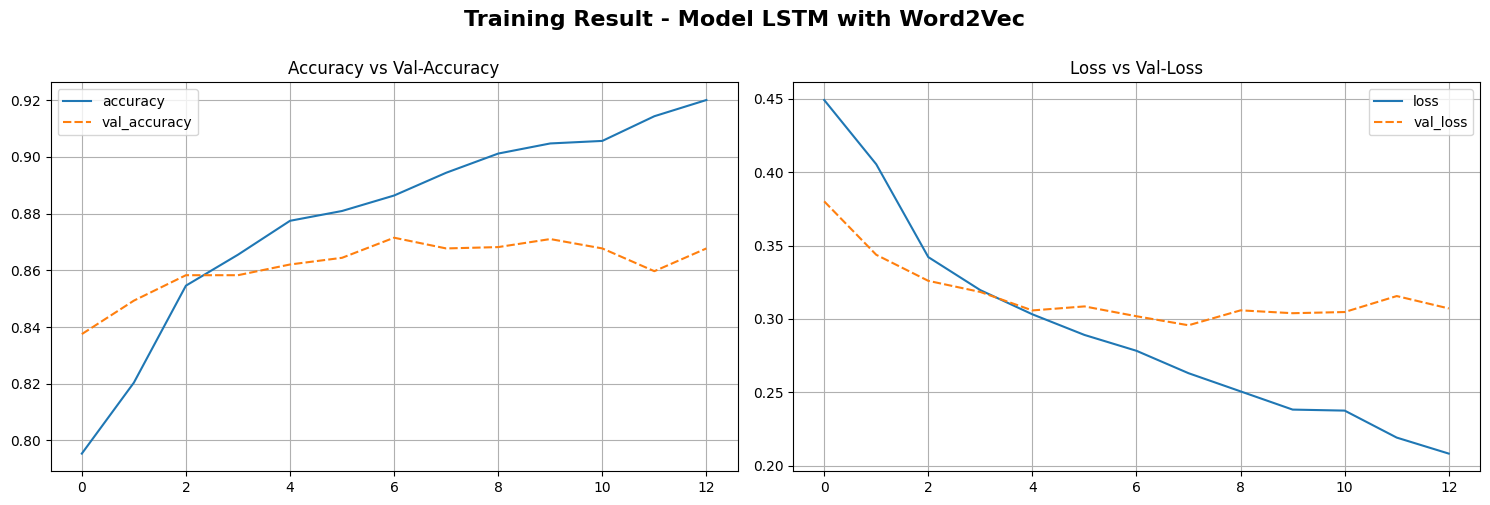

In [46]:
# plot training results

model_lstm_3_hist_df = pd.DataFrame(model_lstm_3_hist.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=model_lstm_3_hist_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')

plt.subplot(1, 2, 2)
sns.lineplot(data=model_lstm_3_hist_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

# set overall title
plt.suptitle('Training Result - Model LSTM with Word2Vec', fontsize = 16, fontweight = 'bold', y = 1)
plt.tight_layout()
plt.show()

By above plot, we have results for this improvement model with closer gap between train and validation set. Note that as we mentioned earlier, the training process is stopped on the 13th iteration (`epoch`) due to **EarlyStopping** `callbacks` that defined when training process. The result is, the training process is stop before overfitting worsen. By this plot, also by historical training data earlier, it is obvious that this model results with better performance than ANN training models (first and second model), because less variance model.

The size of total parameters of this model, now 26.30 MB less than first ANN training model (with 33.63 MB size). Even though the size higher than second ANN training model (with 4.95 MB size), but the trade off still favorable because less variance model. Sure in the future, we need the implemented model is the one that less overfitting rather than low size but with high overfitting tendency.

### vii.3.1. Final Model Evaluation with Confusion Matrix

We can also note that, since the **EarlyStopping** defined earlier have parameter `restore_best_weights=True`, so the model will save the epoch with lowest value that being monitored (`val_loss`), that is on 9th epoch `val_loss: 0.2882`. The resulted model on this 9th epoch is what will be used for the further process.

We can also notice the **accuracy**, as our primary evaluation metric, have close gap between training and validation set. On the train set the accuracy is 90.33 % and for the validation set is 87.95 %, we conclude this result as **good fit**. Since the validation set is expected to be test set representation on the training process, we shall expect the result that close with **test set** for **real evaluation**.

As mentioned earlier, the first and second model in **ANN Training** section not performed evaluation on the **test set** because the result on both previous model (first and second model) are poor. Since ended up we chosen the third model (improvement model in this section), we will done the real evaluation on the **test set** for final evaluation on this model:

In [47]:
# use final model (improvement model):

# will use the result of epoch when best weights
y_pred_test_proba = model_lstm_3.predict(X_test_vec) # predict on test set -- use X_test_vec
y_pred_test = np.where(y_pred_test_proba >= 0.5, 1, 0) # since we use default threshold

print(classification_report(y_test, y_pred_test))

2026-04-28 03:11:05.951459: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      1871
           1       0.91      0.84      0.87      1865

    accuracy                           0.88      3736
   macro avg       0.88      0.88      0.88      3736
weighted avg       0.88      0.88      0.88      3736



The above output shows the result for the test set (which have not touched untl now) for this selected final model is **88 % accuracy**. This amount is still considered good since previously we know that accuracy on the train set is 90.33 %, the gap is small (less than 5%). Hence, the final selected model is less bias and less variance, we will use this for the further process later.

### vii.3.2. Advantages of the Model

We will evaluate the **advantages** and **weakness** of the selected final model, that is what reviews from the test set that the model predicted correctly (advantages) and incorrectly (weakness). We can evaluate by see what words that more frequents in both kind (advantages and weakness of model) of group.

First of all, we need to contatenate the text set (`X_test`), the prediction sentiment (`y_pred_test`), and actual sentiment (`y_test`) to one data frame:

In [48]:
y_test_df = pd.DataFrame(y_test).reset_index(drop=True)
y_test_df.columns = ['y_actual']

concat_test = pd.concat([
    X_test.reset_index(drop=True), # preprocessed text for test set
    y_test_df,
    pd.DataFrame(y_pred_test, columns = ['y_pred'])
], axis = 1) # column-wise

# see the column of created dataframe
concat_test.columns

Index(['text', 'y_actual', 'y_pred'], dtype='object')

Next, as mentioned earlier, advantages of the model is when the model **correctly predicted** sentiment of the review text. There are two kinds **True Positive** where positive sentiments are predicted positive and **True Negative** where negative sentiments are predicted negative.
> Remember that in this dataset, positive sentiments is labelled 0, while negative is labelled 1

In [49]:
# define true positive
# both actual and prediction are values 0
concat_test_TP = concat_test[(concat_test['y_actual'] == 0) & (concat_test['y_pred'] == 0)]

# count frequency of words

all_text = ' '.join(concat_test_TP['text'].values) # flatten all text into a single string
tokens = nltk.word_tokenize(all_text) # tokenize

# define list for all word in the tokens
all_words = []
for token in tokens: # loop for each token
  all_words.append(token)

# define dataframe to store all words earlier
words_TP_df = pd.DataFrame({'word' : all_words})

# see the frequencies with value_counts method
# for example, we will see top 20 words
pd.DataFrame(words_TP_df['word'].value_counts()[:20]).T # to dataframe and transpose

word,not,but,one,like,so,veri,time,stori,more,good,see,charact,get,make,great,would,watch,love,well,also
count,3798,2776,1869,1365,1216,1153,1086,1037,1024,1020,995,965,921,909,902,894,863,851,811,749


In [50]:
# define true negative
# both actual and prediction are values 1
concat_test_TN = concat_test[(concat_test['y_actual'] == 1) & (concat_test['y_pred'] == 1)]

# count frequency of words

all_text = ' '.join(concat_test_TN['text'].values) # flatten all text into a single string
tokens = nltk.word_tokenize(all_text) # tokenize

# define list for all word in the tokens
all_words = []
for token in tokens: # loop for each token
  all_words.append(token)

# define dataframe to store all words earlier
words_TN_df = pd.DataFrame({'word' : all_words})

# see the frequencies with value_counts method
# for example, we will see top 20 words
pd.DataFrame(words_TN_df['word'].value_counts()[:20]).T # to dataframe and transpose

word,not,but,one,like,so,would,no,bad,even,time,watch,make,get,good,see,realli,charact,could,more,scene
count,4625,2592,1561,1402,1346,1102,1014,999,991,974,973,963,936,846,810,792,778,737,706,695


The results for both output above is for both true positive and true negative case, top 20 words from review sentiments that **the model correctly predicted** for each positive and negative sentiments. The result is for the case when model correctly predicted **positive sentiments**, **most words** contains on such reviews have good perceptive such as **`veri`, `good`, `more`, `great`, and `love`**. On the other hand, for the case of **negative sentiments**, the model correctly predicted for most words on the reviews with unfavorable words such as **`bad` and `no`**.

However, we should take a note that on both positive and negative sentiments, **there are some words that overlap and mostly used for both case**. These words are **`not`, `but`, `one`, `like`, `so`, `make`, and `would`**. This mean that these words are not represents one of positive or negative sentiments, instead explain **functional words**. This happened because there may reviews that explain in the **roundabout way** (explain with negative but the true meaning for positive), or **sarcasm** reviews (explain with positive but actual meaning for negative). This is one of the most challenges for NLP modeling case, which means there are still rooms for further improvement.

### vii.3.3. Weakness of the Model

For the weakness of the model, as mentioned earlier, is when the model **incorrectly predicted** sentiment of the review text. There are two kinds **False Positive** where negative sentiments are predicted positive and **False Negative** where positive sentiments are predicted negative.
> Remember that in this dataset, positive sentiments is labelled 0, while negative is labelled 1

In [51]:
# define false positive
# prediction values 0 -- actual values 1 (negative)
concat_test_FP = concat_test[(concat_test['y_actual'] == 1) & (concat_test['y_pred'] == 0)]

# count frequency of words

all_text = ' '.join(concat_test_FP['text'].values) # flatten all text into a single string
tokens = nltk.word_tokenize(all_text) # tokenize

# define list for all word in the tokens
all_words = []
for token in tokens: # loop for each token
  all_words.append(token)

# define dataframe to store all words earlier
words_FP_df = pd.DataFrame({'word' : all_words})

# see the frequencies with value_counts method
# for example, we will see top 20 words
pd.DataFrame(words_FP_df['word'].value_counts()[:20]).T # to dataframe and transpose

word,not,but,one,like,so,would,more,charact,veri,get,make,good,see,watch,time,much,look,stori,realli,no
count,897,592,325,308,246,201,189,179,167,167,165,163,161,160,159,155,150,149,140,140


In [52]:
# define false negative
# prediction values 1 -- actual values 0 (positive)
concat_test_FN = concat_test[(concat_test['y_actual'] == 0) & (concat_test['y_pred'] == 1)]

# count frequency of words

all_text = ' '.join(concat_test_FN['text'].values) # flatten all text into a single string
tokens = nltk.word_tokenize(all_text) # tokenize

# define list for all word in the tokens
all_words = []
for token in tokens: # loop for each token
  all_words.append(token)

# define dataframe to store all words earlier
words_FN_df = pd.DataFrame({'word' : all_words})

# see the frequencies with value_counts method
# for example, we will see top 20 words
pd.DataFrame(words_FN_df['word'].value_counts()[:20]).T # to dataframe and transpose

word,not,but,one,like,so,get,good,make,watch,see,time,would,no,go,charact,realli,think,even,stori,veri
count,402,289,181,164,135,109,103,100,99,99,98,95,92,82,78,74,73,72,70,70


The results for both output above is for both false positive and false negative case, top 20 words from review sentiments that **the model incorrectly predicted** for actual review positive and negative sentiments. The result is when the model incorrectly predicted **positive sentiments** (actual value is negative), **most words** contain reviews with good perceptive such as **`veri`, `good`, `realli`, and `much`**, which the words that similar on true positive case previously. On the other hand, for the case of **negative sentiments** (actual value is positive), the model incorrectly predicted for **most words** on the reviews with unfavorable words that is **`no`**, same word on true negative case previously.

This result means that the model still have some incorrect predictions that assume words as previous to be positive (for false positive case) and negative (for false negative case) sentiments. Perhaps this result due to some reviews with roundabout and sarcasms way explain earlier. However, since the result for this test set as scenario for future unseen data, have 88 % accuracy on model performance earlier. This means that these incorrect prediction case, only on some small cases that is 11% of all test set. While the model still not perfect, this result may considered as a good one for future deployment of this model.

Additionally, both false positive and false negative case also have **functional words** that is **`not`, `but`, `one`, `like`, `so`, `make`, and `would`**, same with true positive and true negative case earlier. This mean that indeed there are still rooms for further improvement for next model creation. Perhaps by remove these words may result the model with better performance for separation between positive and negative sentiments.

# viii. Model Saving

The selected final model that is improvement model is what will be use further deployed on the **Hugging Face platform**. Previously saved to the variable `model_lstm_3` will be saved to the file `sentiment_model.keras` for further data inference. However, we need to freeze this ANN model first so will not caused error when deployed later.

In [53]:
# freeze model
model_lstm_3.trainable = False
model_lstm_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │     6,848,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 64)        │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,982,249 (26.64 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,893,349 (26.30 MB)

 Optimizer params: 88,900 (347.27 KB)

After freeze the model, we can save for future model inference. Since we ended up used model with Word2Vec, we will also save the **tokenizer** that previously fitted with train set in the file `tokenizer`:

In [54]:
# save RNN model as final model
model_lstm_3.save('sentiment_model.keras', include_optimizer=True)

# save tokenizer
with open('tokenizer.pkl', 'wb') as file0:
  pickle.dump(tokenizer, file0)

# ix. Conclusion

Earlier process on **EDA** section, the analysis upon answering below questions:

1. What is the percentage of positive and negative sentiments in this dataset?
2. How is the distribution of number of words for each positive and negative sentiments in this dataset?
3. What are the most frequent words (tokens) in the dataset (corpus)? Do these words carry meaningful sentiment signals, or are they mostly functional words (i.e. stop words)?

We have done on the **EDA** section above by using pure historical dataset with explanation. From the exploratory analysis, we found that the target variable sentiments are balanced, this result is the reason we used **accuracy as metric evaluation** in modeling process.

After inspected the distribution of number of words for each positive and negative sentiments, resulted with both have positive skewed distribution. This result indicates some outliers, which means **there are some sentiments with high number of words but in average not as many as the maximum one**.

The result from 3rd EDA is we found that **some top frequent words are listed on stop words that imported from `nltk` library**. In the end, it was chosen to **include some words** (not removed it in Feature Engineering section) that have **meaningful sentiment signals** such as words that shows negation, intensifier, and contrast things. It was also chosen to **add more stop words** (removed it in Feature Engineering section) that not listed from `nltk` library, that is **`film` and `movie`**, since for this dataset not give additional meaningful to separate between positive and negative sentiments from IMDb reviews.

---

In this project, we have done comparison model on the section **ANN Training** and **ANN Improvement**. The model is used LSTM network, variant of RNN under ANN framework, to handle this NLP problem for **sentiment analysis**. The metric evaluation being used is **accuracy** since the dataset is balanced.

On the section **ANN Training** first model creation is with Bidirectional LSTM model with two layers, with embedding and text vectorization predefined. The result of this **first model for 30 epochs is overfit** the more the model is trained. The **embedding and vectorization** use **maximum tokens** as total vocabulary and **maximum sequence length** as the parameters that used.

For the **second model** (still in ANN Training section) created with **similar with first model but less complexity**. Redefine vectorization and embedding that **use less tokens and less sequence length**, also only use 1 layer of Bidirectional LSTM, with more dropout percentage. The result for this **second model**, similar with first model, is haved overfitting tendency and with **30 epochs the more overfit** (training set good performance but validation set poor performance).

By the result of first and second model in ANN Training section, it is infered that we need another approach to **stop overfitting** before occurred, also use another way that is **pre-trained model**. These steps are done on **ANN Improvement** section with improvement model (third model) creation, that used `callbacks` to prevent overfitting tendency. On the improvement model also used the developed word embeddings `Word2Vec` that learn from tokens vocabulary in this dataset (when first defined), then act as **pre-trained model** that freezed when training core model (third model). The result on this last model created is **good fit** with performance on the test set is 88%, while the training and validation set is 87 - 90 %.

Previous last model is the one that will be used further for **model inference** and **model deployment**. The results of this selected final model, have advantages and weaknesses of model, that is type of words on reviews sentiment data that most occurred when model predicted correctly and incorrectly. The model still shows difficulty in handling ambiguous and overlapping words that may appear in both positive and negative sentiments. Despite its limitations, the model shows good generalization performance and still have 88 % accuracy for the test set that act as unseen dataset.

With this model, movie reviews platforms such as IMDb (as the source of reviews sentiments of this dataset) may utilize sentiment classification to monitor customer feedback, identify negative perceived movies, and highlight most favorable ones. Although the model still has limitations, it demonstrates how sentiment classification can support data-driven decision making for maintaining reputation and improving service quality.

---

As below suggestions can be implemented for further improvement of the model creation:

1. Consider to **remove more words that overlap** within positive and negative sentiments, such as **`not`, `but`, `one`, `like`, `so`, `make`, and `would`**.
2. Perform analysis on model with another algorithm **GRU** from RNN, that less complexity than LSTM.
3. Conduct modeling with **more IMDb reviews dataset** for model creation from scratch able to understand more sentiments